# 01.01 What Does an A/B Test Estimate?

A/B Test 的核心不是简单比较两个数字，而是估计一个产品改动对用户行为指标的因果影响。

在一个典型实验中：

- A 组：Control Group，对照组，看到旧版本；
- B 组：Treatment Group，实验组，看到新版本；
- Metric：实验指标，例如转化率、留存率、人均收入、平均游戏局数等；
- Effect：实验组相对于对照组的指标变化。

从业务角度看，A/B Test 回答的问题是：

> 如果我们把新版本上线给所有用户，核心指标会发生什么变化？

从统计角度看，A/B Test 估计的是处理效应，也就是 Treatment Effect。

## Potential Outcome Framework

对每个用户 \(i\)，理论上存在两个潜在结果：

$$
Y_i(1)
$$

表示用户 \(i\) 看到实验版本后的结果；

$$
Y_i(0)
$$

表示用户 \(i\) 看到对照版本后的结果。

但是现实中，每个用户只能看到一个版本，所以我们只能观察到：

$$
Y_i = T_iY_i(1) + (1 - T_i)Y_i(0)
$$

其中：

$$
T_i =
\begin{cases}
1, & \text{用户进入 Treatment Group} \\
0, & \text{用户进入 Control Group}
\end{cases}
$$

A/B Test 最关心的是平均处理效应：

$$
ATE = E[Y_i(1) - Y_i(0)]
$$

在随机分流成立时，可以用两组样本均值之差估计它：

$$
\hat{\tau} = \bar{Y}_T - \bar{Y}_C
$$

其中：

$$
\bar{Y}_T = \frac{1}{n_T}\sum_{i:T_i=1}Y_i
$$

$$
\bar{Y}_C = \frac{1}{n_C}\sum_{i:T_i=0}Y_i
$$

## 一个模拟例子

### 生成模拟数据

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 固定随机数种子
rng = np.random.default_rng( seed=42 )

In [3]:
# 设置模拟参数
n_users = 10000
p_control = 0.10
p_treatment = 0.12

In [4]:
# 随机分流用户
group = rng.choice(a=["control", "treatment"], size=n_users, p=[0.5, 0.5])
group

array(['treatment', 'control', 'treatment', ..., 'control', 'control',
       'control'], shape=(10000,), dtype='<U9')

In [5]:
# 对随机分配用户进行转化模拟
converted = np.where(
    group == "control",
    rng.binomial(n=1, p=p_control, size=n_users),
    rng.binomial(n=1, p=p_treatment, size=n_users)
)
converted

array([0, 0, 0, ..., 0, 0, 0], shape=(10000,))

In [6]:
# 生成模拟数据
df = pd.DataFrame(data={
    "user_id": np.arange(1, n_users + 1),
    "group": group,
    "converted": converted
})
df

,user_id,group,converted
0,1,treatment,0
1,2,control,0
2,3,treatment,0
3,4,treatment,0
4,5,control,0
...,...,...,...
9995,9996,control,0
9996,9997,control,0
9997,9998,control,0
9998,9999,control,0


### 计算模拟转化

In [7]:
summary = df.groupby(by=["group"]).agg(
    users = ("user_id", "count"),
    conversions = ("converted", "sum"),
    conversion_rate = ("converted", "mean")
).reset_index()
summary

,group,users,conversions,conversion_rate
0,control,5015,514,0.102493
1,treatment,4985,593,0.118957


In [8]:
# 计算实验效果
convertion_rate = summary.loc[summary["group"] == "control", "conversion_rate"].iloc[0]
treatment_rate = summary.loc[summary["group"] == "treatment", "conversion_rate"].iloc[0]

absolute_lift = treatment_rate - convertion_rate
relative_lift = (treatment_rate - convertion_rate) / convertion_rate

convertion_rate, treatment_rate, absolute_lift, relative_lift

(np.float64(0.10249252243270189),
 np.float64(0.1189568706118355),
 np.float64(0.016464348179133614),
 np.float64(0.1606395060668387))

### 绘制分组结果

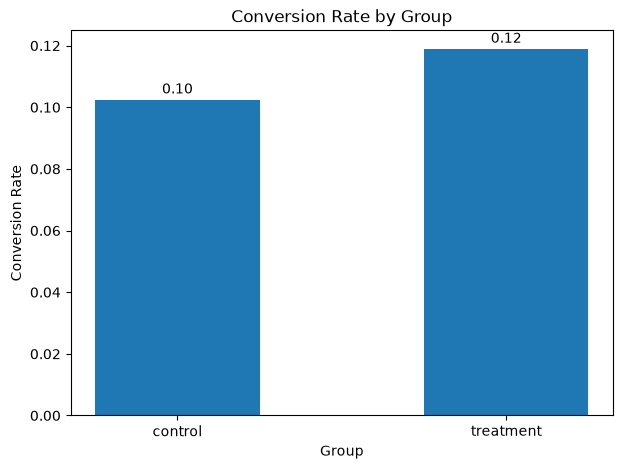

In [9]:
fig, ax = plt.subplots(figsize=(7,5))

ax.bar(x=summary["group"], height=summary["conversion_rate"], width=0.5)
ax.set_title("Conversion Rate by Group")
ax.set_xlabel("Group")
ax.set_ylabel("Conversion Rate")

for i,value in enumerate(summary["conversion_rate"]):
    ax.text(x=i, y=value + 0.002, s=f"{value:.2f}", ha="center")

plt.show()

# 01.02 Why Random Assignment Supports Causal Interpretation

A/B Test 的核心前提是随机分流。

如果用户被随机分到 Control Group 和 Treatment Group，那么实验组和对照组在实验开始前的用户特征上，理论上应该是相似的。

这些特征包括：

- 用户活跃度；
- 付费倾向；
- 游戏水平；
- 历史消费；
- 设备类型；
- 国家或地区；
- 新老用户状态；
- 对产品功能的偏好。

随机分流的目的不是让每一个用户都一样，而是让两组用户在整体分布上相似。

因此，如果实验后 Treatment 组和 Control 组的指标出现系统性差异，我们才更有理由把这个差异解释为 Treatment 造成的影响。

## Mathematical Idea

在潜在结果框架下，每个用户都有两个潜在结果：

$$
Y_i(1)
$$

表示用户 $i$ 接受 Treatment 后的结果。

$$
Y_i(0)
$$

表示用户 $i$ 接受 Control 后的结果。

随机分流意味着：

$$
T_i \perp (Y_i(1), Y_i(0))
$$

这表示用户是否进入 Treatment Group，与用户本身的潜在结果无关。

换句话说：

$$
E[Y_i(1) \mid T_i = 1] = E[Y_i(1)]
$$

$$
E[Y_i(0) \mid T_i = 0] = E[Y_i(0)]
$$

所以：

$$
E[Y_i \mid T_i = 1] - E[Y_i \mid T_i = 0]
= E[Y_i(1)] - E[Y_i(0)]
$$

也就是：

$$
E[\bar{Y}_T - \bar{Y}_C] = ATE
$$

因此，在随机分流成立时，两组样本均值之差可以作为平均处理效应的估计量。

## 一个模拟例子

In [10]:
n_users = 10_000

In [11]:
# 模拟用户类型
user_type = rng.choice(
    a=["Low Intent", "High Intent"],
    size=n_users,
    p=[0.7, 0.3]
)
user_type

array(['Low Intent', 'Low Intent', 'High Intent', ..., 'High Intent',
       'Low Intent', 'Low Intent'], shape=(10000,), dtype='<U11')

In [12]:
# 模拟不同类型的用户转化率
baseline_conversion_rate = np.where(
    user_type == "High Intent",
    0.20,
    0.05
)
baseline_conversion_rate

array([0.05, 0.05, 0.2 , ..., 0.2 , 0.05, 0.05], shape=(10000,))

In [13]:
# 生成模拟数据
users = pd.DataFrame(data={
    "user_id": np.arange(1, n_users + 1),
    "user_type": user_type,
    "baseline_conversion_prob": baseline_conversion_rate
})
users

,user_id,user_type,baseline_conversion_prob
0,1,Low Intent,0.05
1,2,Low Intent,0.05
2,3,High Intent,0.20
3,4,Low Intent,0.05
4,5,Low Intent,0.05
...,...,...,...
9995,9996,High Intent,0.20
9996,9997,High Intent,0.20
9997,9998,High Intent,0.20
9998,9999,Low Intent,0.05


### 随机分流情况

In [14]:
# 随机分流情况
random_df = users.copy()
random_df["group"] = rng.choice(
    a=["Control", "Treatment"],
    size=n_users,
    p=[0.5, 0.5]
)

# Treatment没有效果，转化率只与用户的类型有关
random_df["converted"] = rng.binomial(
    n=1,
    p=random_df["baseline_conversion_prob"]
)

random_df

,user_id,user_type,baseline_conversion_prob,group,converted
0,1,Low Intent,0.05,Control,0
1,2,Low Intent,0.05,Control,0
2,3,High Intent,0.20,Control,0
3,4,Low Intent,0.05,Control,0
4,5,Low Intent,0.05,Treatment,0
...,...,...,...,...,...
9995,9996,High Intent,0.20,Treatment,0
9996,9997,High Intent,0.20,Control,0
9997,9998,High Intent,0.20,Treatment,0
9998,9999,Low Intent,0.05,Treatment,0


In [15]:
# 在这种情况下计算两组平均转化率
random_summary = random_df.groupby(by=["group"]).agg(
    users=("user_id", "count"),
    conversions=("converted", "sum"),
    conversion_rate=("converted", "mean")
)
random_summary

,users,conversions,conversion_rate
group,,,
Control,4961,459,0.092522
Treatment,5039,496,0.098432


In [16]:
# 检查两组用户的构成
pd.crosstab(
    random_df["group"],
    random_df["user_type"],
    normalize="index"
)

user_type,High Intent,Low Intent
group,,
Control,0.300746,0.699254
Treatment,0.307204,0.692796


### 非随机分流情况

In [17]:
biased_df = users.copy()

# 非随机分流：假设高意向用户更容易进入Treatment
treatment_prob = np.where(
    biased_df["user_type"] == "High Intent",
    0.80,
    0.40
)

## 随后对用户进行分组
biased_df["group"] = np.where(
    rng.binomial(n=1, p=treatment_prob) == 1,
    "Treatment",
    "Control"
)

# Treatment没有真实效果
biased_df["converted"] = rng.binomial(
    n=1,
    p=biased_df["baseline_conversion_prob"]
)
biased_df

,user_id,user_type,baseline_conversion_prob,group,converted
0,1,Low Intent,0.05,Treatment,0
1,2,Low Intent,0.05,Treatment,0
2,3,High Intent,0.20,Control,0
3,4,Low Intent,0.05,Treatment,0
4,5,Low Intent,0.05,Control,0
...,...,...,...,...,...
9995,9996,High Intent,0.20,Treatment,0
9996,9997,High Intent,0.20,Treatment,0
9997,9998,High Intent,0.20,Treatment,0
9998,9999,Low Intent,0.05,Treatment,0


In [19]:
# 计算分组转化率
biased_summary = biased_df.groupby(by="group").agg(
    users=("user_id", "count"),
    conversions=("converted", "sum"),
    conversion_rate=("converted", "mean")
).reset_index()
biased_summary

,group,users,conversions,conversion_rate
0,Control,4795,372,0.077581
1,Treatment,5205,658,0.126417


In [37]:
# 检查用户构成
biased_balance = pd.crosstab(
    index=biased_df["group"],
    columns=biased_df["user_type"],
    normalize="index"
)
biased_balance

user_type,High Intent,Low Intent
group,,
Control,0.129093,0.870907
Treatment,0.465130,0.534870
